# Formula 1 Race Winner Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                            roc_curve, precision_recall_fscore_support, accuracy_score, 
                            f1_score, precision_recall_curve)
os.makedirs('out/images', exist_ok=True)

## Load the Data
We load all the CSV files from the `data` directory.

In [2]:
circuits = pd.read_csv('data/circuits.csv')
constructor_results = pd.read_csv('data/constructor_results.csv')
constructor_standings = pd.read_csv('data/constructor_standings.csv')
constructors = pd.read_csv('data/constructors.csv')
driver_standings = pd.read_csv('data/driver_standings.csv')
drivers = pd.read_csv('data/drivers.csv')
lap_times = pd.read_csv('data/lap_times.csv')
pit_stops = pd.read_csv('data/pit_stops.csv')
qualifying = pd.read_csv('data/qualifying.csv')
races = pd.read_csv('data/races.csv')
results = pd.read_csv('data/results.csv')
seasons = pd.read_csv('data/seasons.csv')
sprint_results = pd.read_csv('data/sprint_results.csv')
status = pd.read_csv('data/status.csv')

df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'date']], on='raceId')
df = df.merge(drivers[['driverId', 'driverRef', 'nationality', 'dob']], on='driverId')
df = df.merge(constructors[['constructorId', 'constructorRef', 'nationality']], on='constructorId', suffixes=('_driver', '_constructor'))
df = df.merge(circuits[['circuitId', 'circuitRef', 'country', 'lat', 'lng']], on='circuitId')
df = df.merge(status[['statusId', 'status']], on='statusId', how='left')

print(f"Main Dataframe Shape: {df.shape}")

Main Dataframe Shape: (26759, 32)


## Data Preprocessing
- Handle missing values (replace mapped `\N` with NaN)
- Convert data types (dates, numerics)

In [3]:
# Replace '\N' with NaN
df.replace('\\\\N', np.nan, inplace=True)
# Convert date columns
df['date'] = pd.to_datetime(df['date'])
df['dob'] = pd.to_datetime(df['dob'])
# Convert numeric columns that might be strings
numeric_cols = ['grid', 'positionOrder', 'points', 'laps']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaNs if appropriate (e.g. 0 points)
df = df.fillna({'points': 0})
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   resultId                 26759 non-null  int64         
 1   raceId                   26759 non-null  int64         
 2   driverId                 26759 non-null  int64         
 3   constructorId            26759 non-null  int64         
 4   number                   26759 non-null  str           
 5   grid                     26759 non-null  int64         
 6   position                 26759 non-null  str           
 7   positionText             26759 non-null  str           
 8   positionOrder            26759 non-null  int64         
 9   points                   26759 non-null  float64       
 10  laps                     26759 non-null  int64         
 11  time                     26759 non-null  str           
 12  milliseconds             26759 non-null  st

## Exploratory Data Analysis (EDA)
Visualizing the data and saving plots to `out/images`.

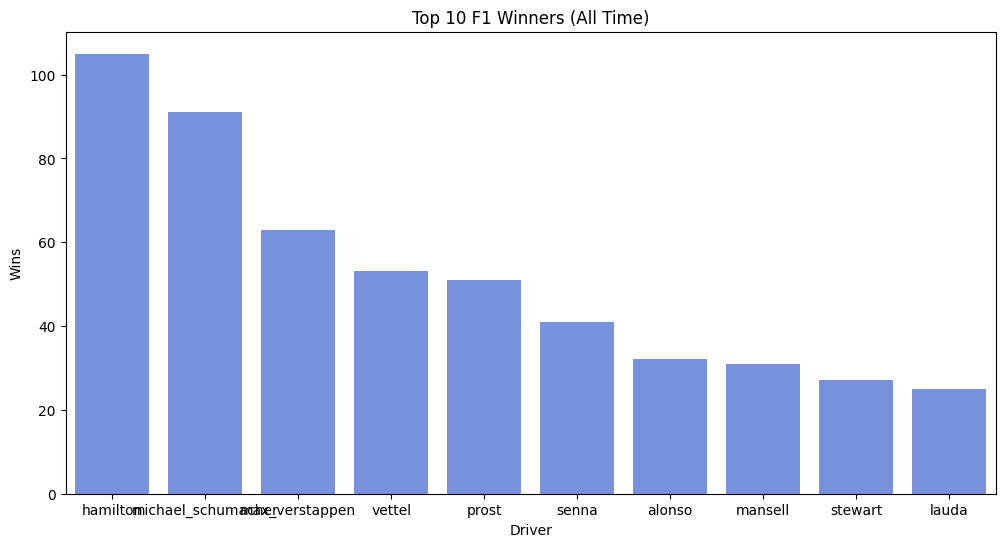

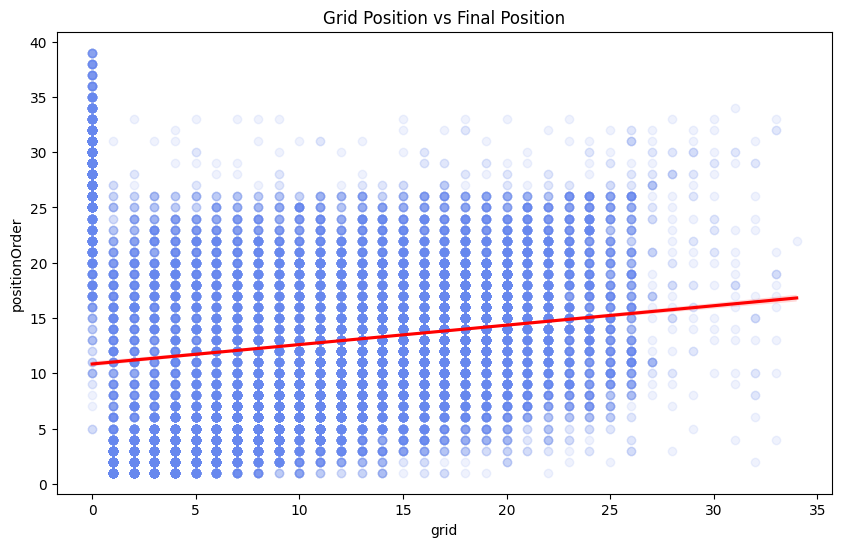

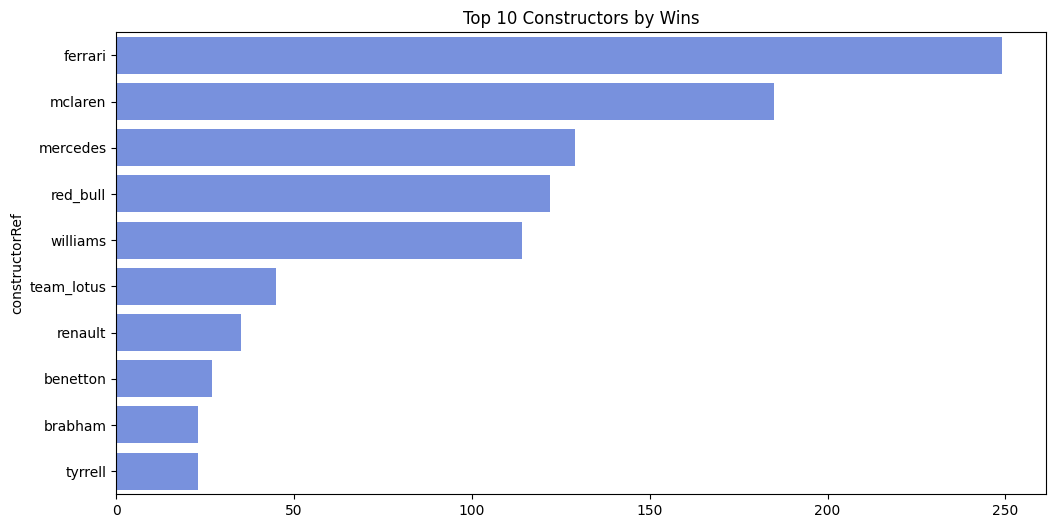

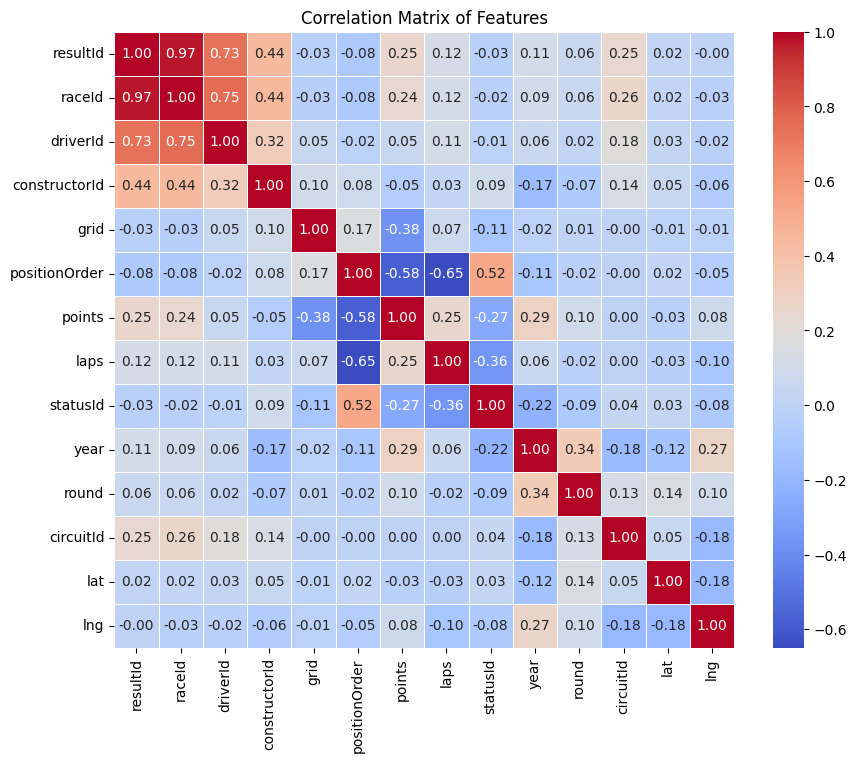

In [4]:
sns.set_palette("coolwarm")

# 1. Top 10 Winners
plt.figure(figsize=(12, 6))
top_winners = df[df['positionOrder'] == 1]['driverRef'].value_counts().head(10)
sns.barplot(x=top_winners.index, y=top_winners.values)
plt.title('Top 10 F1 Winners (All Time)')
plt.ylabel('Wins')
plt.xlabel('Driver')
plt.savefig('out/images/top_winners.png')
plt.show()

# 2. Grid Position vs Final Position Correlation
plt.figure(figsize=(10, 6))
correlation_data = df[['grid', 'positionOrder']].dropna()
sns.regplot(x='grid', y='positionOrder', data=correlation_data, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Grid Position vs Final Position')
plt.savefig('out/images/grid_pos_correlation.png')
plt.show()

# 3. Constructor Wins
plt.figure(figsize=(12, 6))
top_constructors = df[df['positionOrder'] == 1]['constructorRef'].value_counts().head(10)
sns.barplot(x=top_constructors.values, y=top_constructors.index, orient='h')
plt.title('Top 10 Constructors by Wins')
plt.savefig('out/images/constructor_wins.png')
plt.show()

# 4. Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.savefig('out/images/correlation_matrix.png')
plt.show()

## Feature Engineering
Creating features for the model.
- `Driver Age`: Age of driver at race date
- `Cumulative Points`: Points earned BEFORE this race (fixes data leakage)<br>
- `Target`: 1 if winner (`positionOrder` == 1), else 0

In [5]:
# Calculate Driver Age
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25
# Create Target Variable
df['is_winner'] = df['positionOrder'].apply(lambda x: 1 if x == 1 else 0)

# Encode Categorical Variables
le_driver = LabelEncoder()
le_constructor = LabelEncoder()
le_circuit = LabelEncoder()

df['driverId_enc'] = le_driver.fit_transform(df['driverRef'])
df['constructorId_enc'] = le_constructor.fit_transform(df['constructorRef'])
df['circuitId_enc'] = le_circuit.fit_transform(df['circuitRef'])

# Calculate Cumulative Points
df = df.sort_values(['driverId', 'date'])
df['cumulative_points'] = df.groupby('driverId')['points'].cumsum().shift(1).fillna(0)

# Select Features (Removed points, laps, etc.)
features = ['grid', 'cumulative_points', 'laps', 'driverId_enc', 'constructorId_enc', 'circuitId_enc', 'driver_age']
target = 'is_winner'

df_model = df[features + [target, 'year']].dropna()
print(df_model.head())

     grid  cumulative_points  laps  driverId_enc  constructorId_enc  \
370     4                0.0    58           345                131   
391     4                6.0    56           345                131   
413     2               14.0    57           345                131   
435     4               22.0    65           345                131   
457     2               30.0    78           345                131   

     circuitId_enc  driver_age  is_winner  year  
370              3   22.190281          0  2007  
391             61   22.247775          0  2007  
413              7   22.266940          0  2007  
435             13   22.343600          0  2007  
457             42   22.381930          0  2007  


## Split Data
We use a temporal split to avoid data leakage (training on future races to predict past ones).
- **Train**: Races before 2023
- **Test**: Races in 2023 and after

In [6]:
train = df_model[df_model['year'] < 2023]
test = df_model[df_model['year'] >= 2023]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

#Adding Feature Scaling
scaler = StandardScaler()
numerical_features = ['grid', 'cumulative_points', 'laps', 'driver_age']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

X_train = X_train_scaled
X_test = X_test_scaled

Train shape: (25840, 7), Test shape: (919, 7)


## Choose Model & Hyperparameter Tuning
Training multiple models and select the best one based on F1-Score.<br>
Given the class imbalance (1 winner vs 19 losers), we use `class_weight='balanced'` for Random Forest

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
best_model_name = ""
best_f1 = 0
best_model = None

print("Training models...")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted F1 for imbalanced classes
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except:
        roc = 0
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1,
        'ROC-AUC': roc
    })
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model = model

print("\nModel Comparison:")
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1-Score', ascending=False))

print(f"\nBest Model: {best_model_name} with F1-Score: {best_f1:.4f}")

Training models...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


d:\Program Files\Programming\Python3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:21:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Gradient Boosting...

Model Comparison:
                 Model  Accuracy  F1-Score   ROC-AUC
4    Gradient Boosting  0.961915  0.960875  0.955787
2        Random Forest  0.966268  0.960865  0.958190
3              XGBoost  0.963003  0.960853  0.970193
0  Logistic Regression  0.953210  0.948133  0.923552
1        Decision Tree  0.930359  0.937916  0.778002

Best Model: Gradient Boosting with F1-Score: 0.9609


## Make Predictions and Evaluate

Evaluating models on Train and Test sets...

Model Comparison (Check for Overfitting):
                 Model  Train Acc  Test Acc  Train F1   Test F1  Test ROC-AUC
4    Gradient Boosting   0.963661  0.961915  0.957536  0.960875      0.955787
2        Random Forest   1.000000  0.966268  1.000000  0.960865      0.958190
3              XGBoost   0.986610  0.963003  0.985777  0.960853      0.970193
0  Logistic Regression   0.956734  0.953210  0.941367  0.948133      0.923552
1        Decision Tree   1.000000  0.930359  1.000000  0.937916      0.778002

Best Model: Gradient Boosting with Test F1-Score: 0.9609

Cross-Validation F1 Scores: 0.9275 (+/- 0.0213)

Detailed Evaluation for Gradient Boosting:
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       873
           1       0.63      0.57      0.60        46

    accuracy                           0.96       919
   macro avg       0.81      0.77      0.79       919

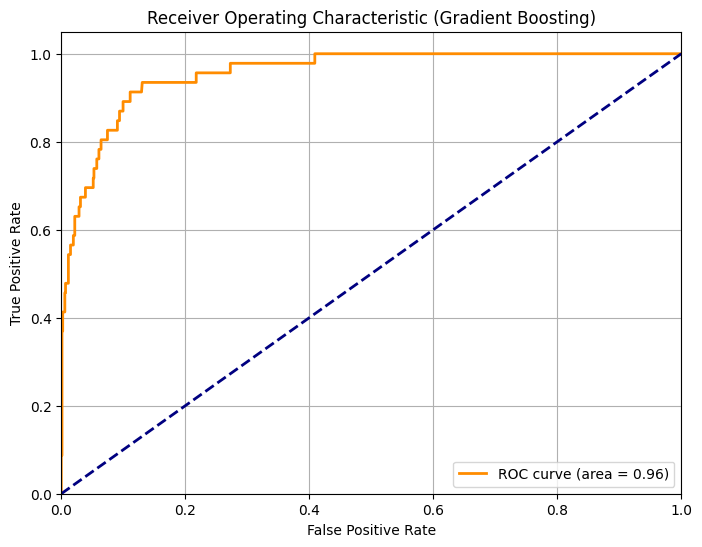


Programmatic Metrics per Class (0: Non-winner, 1: Winner):
Non-winner: Precision=0.9772, Recall=0.9828, F1=0.9800, Support=873
Winner: Precision=0.6341, Recall=0.5652, F1=0.5977, Support=46


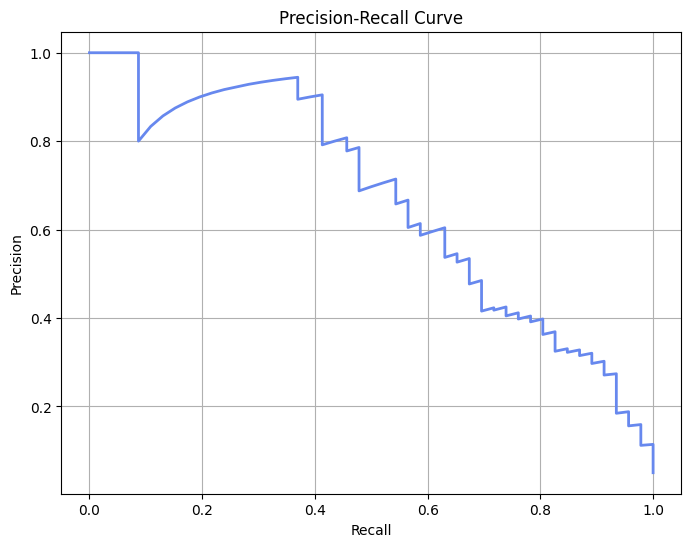


Feature Importance:
             feature  importance
0               grid    0.498681
2               laps    0.363363
1  cumulative_points    0.084882
6         driver_age    0.024778
3       driverId_enc    0.021503
5      circuitId_enc    0.004487
4  constructorId_enc    0.002305


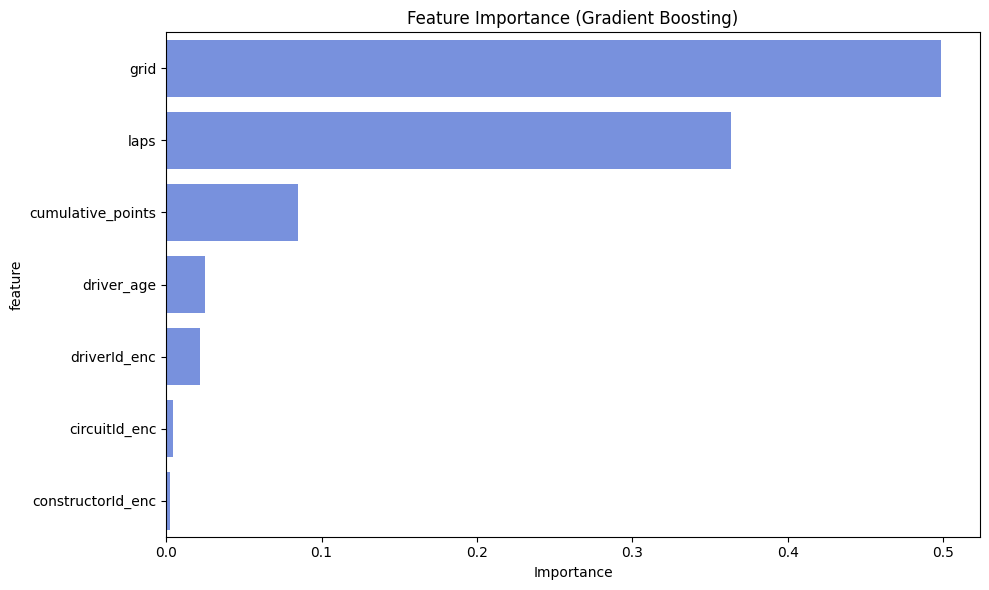

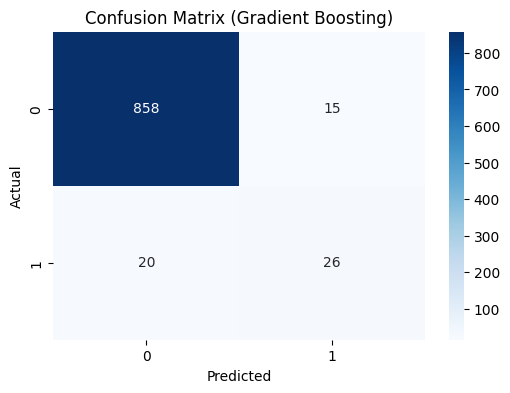

In [8]:
results = []
best_model_name = ""
best_f1 = 0
best_model = None

print("Evaluating models on Train and Test sets...")
for name, model in models.items():
    # Test Set Metrics
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    # Train Set Metrics (to check for overfitting)
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    try:
        y_prob_test = model.predict_proba(X_test)[:, 1]
        roc_test = roc_auc_score(y_test, y_prob_test)
    except:
        roc_test = 0
    results.append({
        'Model': name,
        'Train Acc': acc_train,
        'Test Acc': acc_test,
        'Train F1': f1_train,
        'Test F1': f1_test,
        'Test ROC-AUC': roc_test
    })
    if f1_test > best_f1:
        best_f1 = f1_test
        best_model_name = name
        best_model = model

print("\nModel Comparison (Check for Overfitting):")
results_df = pd.DataFrame(results)
# Reorder columns for easier comparison
results_df = results_df[['Model', 'Train Acc', 'Test Acc', 'Train F1', 'Test F1', 'Test ROC-AUC']]
print(results_df.sort_values(by='Test F1', ascending=False))

print(f"\nBest Model: {best_model_name} with Test F1-Score: {best_f1:.4f}")

#Adding CV
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"\nCross-Validation F1 Scores: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print(f"\nDetailed Evaluation for {best_model_name}:")
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic ({best_model_name})')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('out/images/roc_curve.png')
plt.show()

# Precision, Recall, F-Score Support
precision_s, recall_s, fscore_s, support_s = precision_recall_fscore_support(y_test, y_pred)
print('\nProgrammatic Metrics per Class (0: Non-winner, 1: Winner):')
for i, class_label in enumerate(['Non-winner', 'Winner']):
        print(f'{class_label}: Precision={precision_s[i]:.4f}, Recall={recall_s[i]:.4f}, F1={fscore_s[i]:.4f}, Support={support_s[i]}')

#Precision Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.savefig('out/images/precision_recall_curve.png')
plt.show()

#Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nFeature Importance:")
    print(importance_df)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='importance', y='feature')
    plt.title(f'Feature Importance ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('out/images/feature_importance.png')
    plt.show()


# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('out/images/confusion_matrix.png')
plt.show()

## Saving Model

In [9]:
model_data = {
    'model': best_model,
    'le_driver': le_driver,
    'le_constructor': le_constructor,
    'le_circuit': le_circuit,
    'scaler': scaler,
    'model_name': best_model_name,
    'feature_names': features
}

joblib.dump(model_data, 'out/models/f1_model_data.pkl')
print("Model saved to 'out/models/f1_model_data.pkl'")

Model saved to 'out/models/f1_model_data.pkl'


## Deploying in WebApp

To run the app, execute the following command in your terminal:

```bash
python app.py
```